# Module 1 — Fluorouracil: Exploratory Data Analysis

This notebook performs deeper EDA on the fluorouracil dataset established in `01_5fu_explore.ipynb`.  
The focus shifts from data inventory to analytical findings: adverse reaction profiles, serious outcome distributions, cross-regimen comparisons, and demographic context.

**Prerequisite:** Run `01_5fu_explore.ipynb` first to ensure the `fluorouracil_filtered` table exists in the database.

In [ ]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parents[0]
db_path = project_root / "database" / "faers.db"

conn = sqlite3.connect(db_path)

In [32]:
# Query the FAERS database to get adverse reactions (symptoms)
# associated specifically with Fluorouracil reports


reactions = pd.read_sql_query("""
SELECT
    r.pt AS symptom,
    COUNT(*) AS symptom_count
FROM reac r
JOIN (
    SELECT DISTINCT primaryid
    FROM drug
    WHERE drugname IN (
        'FLUOROURACIL',
        'FLUOROURACIL\\LEUCOVORIN CALCIUM\\OXALIPLATIN',
        'FLUOROURACIL\\IRINOTECAN\\LEUCOVORIN',
        'FLUOROURACIL SODIUM',
        'FLUOROURACIL\\IRINOTECAN\\LEUCOVORIN\\OXALIPLATIN'
    )
) f
    ON r.primaryid = f.primaryid
GROUP BY r.pt
ORDER BY symptom_count DESC;
""", conn)

reactions.head(20)

,symptom,symptom_count
0,Diarrhoea,806
1,Off label use,698
2,Neutropenia,590
3,Nausea,537
4,Disease progression,428
5,Neuropathy peripheral,410
6,Drug ineffective,405
7,Thrombocytopenia,396
8,Malignant neoplasm progression,375
9,Vomiting,371


In [34]:
reactions_for_combos = pd.read_sql_query(r"""
SELECT
    r.pt AS symptom,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL'
        THEN r.primaryid
    END) AS fluorouracil_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN'
        THEN r.primaryid
    END) AS fluorouracil_leucovorin_calcium_oxaliplatin_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL\IRINOTECAN\LEUCOVORIN'
        THEN r.primaryid
    END) AS fluorouracil_irinotecan_leucovorin_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL SODIUM'
        THEN r.primaryid
    END) AS fluorouracil_sodium_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL\IRINOTECAN\LEUCOVORIN\OXALIPLATIN'
        THEN r.primaryid
    END) AS fluorouracil_irinotecan_leucovorin_oxaliplatin_count

FROM reac r
JOIN drug d
    ON r.primaryid = d.primaryid

WHERE d.drugname IN (
    'FLUOROURACIL',
    'FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN',
    'FLUOROURACIL\IRINOTECAN\LEUCOVORIN',
    'FLUOROURACIL SODIUM',
    'FLUOROURACIL\IRINOTECAN\LEUCOVORIN\OXALIPLATIN'
)

GROUP BY r.pt
ORDER BY fluorouracil_count DESC;
""", conn)

reactions_for_combos.head(20)

,symptom,fluorouracil_count,fluorouracil_leucovorin_calcium_oxaliplatin_count,fluorouracil_irinotecan_leucovorin_count,fluorouracil_sodium_count,fluorouracil_irinotecan_leucovorin_oxaliplatin_count
0,Diarrhoea,640,8,7,7,6
1,Off label use,538,21,22,12,6
2,Neutropenia,446,6,7,2,4
3,Nausea,410,9,3,6,3
4,Neuropathy peripheral,335,10,6,1,4
5,Drug ineffective,328,6,3,2,1
6,Disease progression,316,5,8,7,3
7,Vomiting,292,3,2,3,3
8,Thrombocytopenia,285,9,10,5,2
9,Fatigue,284,11,2,5,2


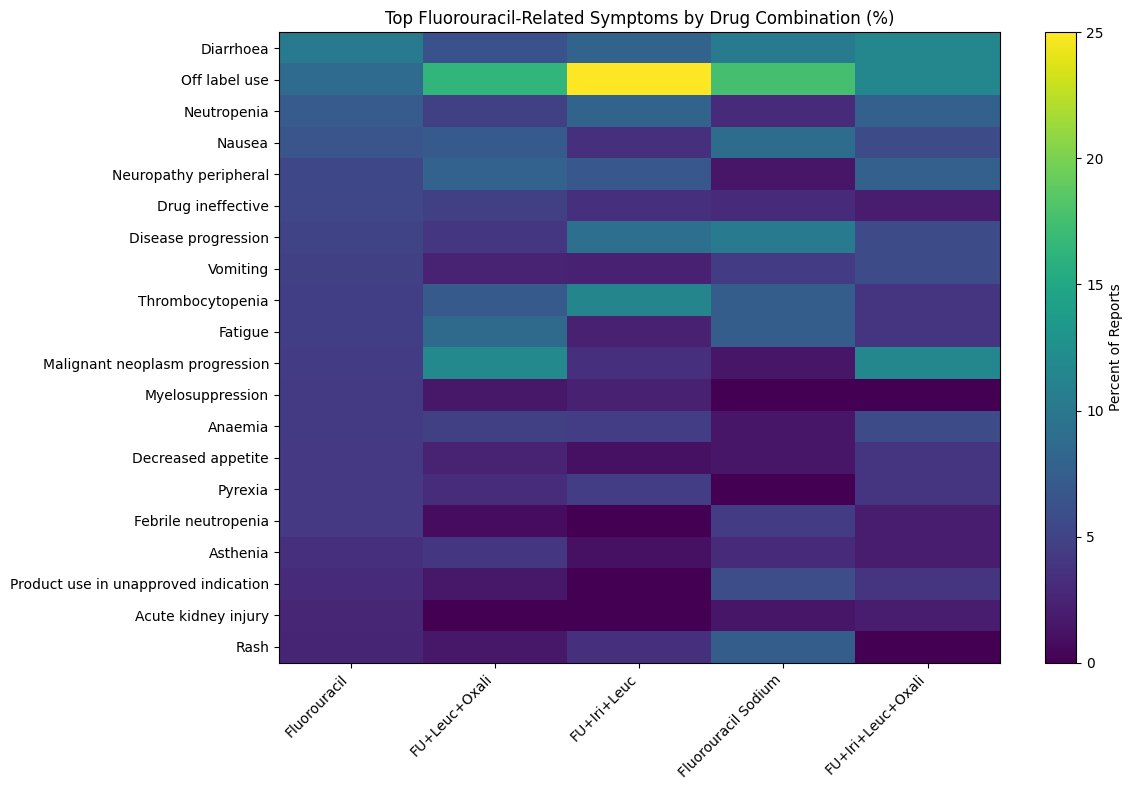

In [ ]:
# Diarrhoea: Frequent loose or watery stools
# Off label use: Drug used outside its approved indication
# Neutropenia: Low neutrophil count (increased infection risk)
# Nausea: Sensation of needing to vomit
# Neuropathy peripheral: Nerve damage causing numbness/tingling in hands or feet
# Drug ineffective: Treatment did not produce intended effect
# Disease progression: Worsening or advancement of disease
# Vomiting: Forceful expulsion of stomach contents
# Thrombocytopenia: Low platelet count (increased bleeding risk)
# Fatigue: Extreme tiredness or lack of energy
# Malignant neoplasm progression: Cancer growth or spread
# Myelosuppression: Reduced bone marrow activity (fewer blood cells produced)
# Anaemia: Low red blood cell count or hemoglobin
# Decreased appetite: Reduced desire to eat
# Pyrexia: Fever
# Febrile neutropenia: Fever with low neutrophils (serious condition)
# Asthenia: General physical weakness
# Product use in unapproved indication: Drug used for a non-approved condition
# Acute kidney injury: Sudden decline in kidney function
# Rash: Skin irritation or eruption
#


import matplotlib.pyplot as plt

# Rename columns to shorter labels for plotting
plot_df = reactions_for_combos.rename(columns={
    "fluorouracil_count": "Fluorouracil",
    "fluorouracil_leucovorin_calcium_oxaliplatin_count": "FU+Leuc+Oxali",
    "fluorouracil_irinotecan_leucovorin_count": "FU+Iri+Leuc",
    "fluorouracil_sodium_count": "Fluorouracil Sodium",
    "fluorouracil_irinotecan_leucovorin_oxaliplatin_count": "FU+Iri+Leuc+Oxali"
})

# Set symptom as index
heatmap_df = plot_df.set_index("symptom")

# Keep top 20 symptoms based on the original ordering
heatmap_df = heatmap_df.head(20)

# Normalize each column independently to percentages
heatmap_pct = heatmap_df.div(heatmap_df.sum(axis=0), axis=1) * 100

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_pct, aspect="auto")
plt.colorbar(label="Percent of Reports")

plt.xticks(
    range(len(heatmap_pct.columns)),
    heatmap_pct.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_pct.index)),
    heatmap_pct.index
)

plt.title("Top Fluorouracil-Related Symptoms by Drug Combination (%)")
plt.tight_layout()
plt.show()  